In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and feature engineering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Keep the notebook clean and reproducible
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_SEED = 42          # the same seed everywhere -> the same results every run
np.random.seed(RANDOM_SEED)

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
FILE_PATH = "synthetic_food_dataset_imbalanced.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully!")
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows   : 31700
Number of columns: 16


In [7]:
# Look at the first 5 rows to see what the data looks like
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [9]:
# The column we want to predict
TARGET_COLUMN = "Food_Name"

print("All columns:", list(df.columns))
print("\nTarget column:", TARGET_COLUMN)

All columns: ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']

Target column: Food_Name


In [11]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

In [13]:
# Basic statistics of the numeric columns (mean, min, max, etc.)
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


In [15]:
numeric_cols     = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = ['Meal_Type', 'Preparation_Method']
boolean_cols     = ['Is_Vegan', 'Is_Gluten_Free']

print("Numerical columns  :", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Boolean columns    :", boolean_cols)

Numerical columns  : ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size']
Categorical columns: ['Meal_Type', 'Preparation_Method']
Boolean columns    : ['Is_Vegan', 'Is_Gluten_Free']


In [17]:
class_counts = df[TARGET_COLUMN].value_counts()

print("Total number of classes:", df[TARGET_COLUMN].nunique())
print("\nSamples per class:")
print(class_counts)

Total number of classes: 10

Samples per class:
Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64


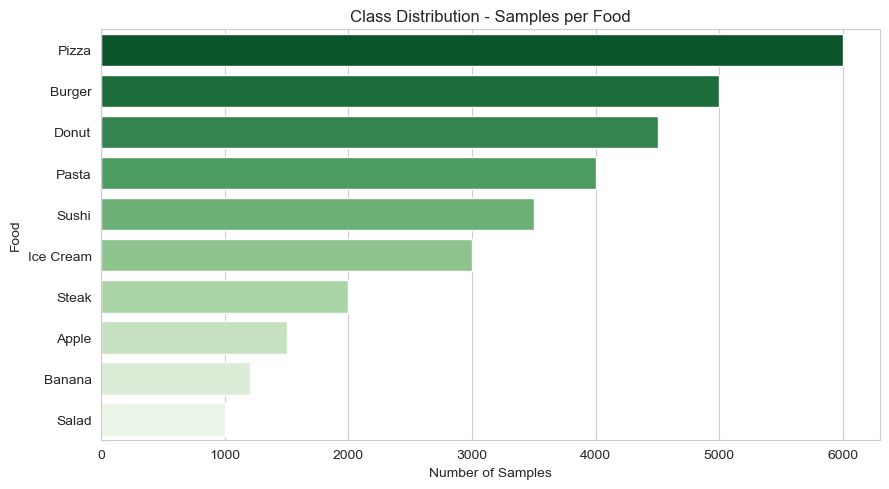

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, palette='Greens_r')
plt.title('Class Distribution - Samples per Food')
plt.xlabel('Number of Samples')
plt.ylabel('Food')
plt.tight_layout()
plt.show()

In [21]:
# Show the imbalance as a ratio
print("Largest class :", class_counts.idxmax(), "-", class_counts.max(), "samples")
print("Smallest class:", class_counts.idxmin(), "-", class_counts.min(), "samples")
print("Imbalance ratio: {:.1f} : 1".format(class_counts.max() / class_counts.min()))

Largest class : Pizza - 6000 samples
Smallest class: Salad - 1000 samples
Imbalance ratio: 6.0 : 1


In [23]:
print("Dataset size  :", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset size  : (31700, 16)
Duplicate rows: 313

Missing values per column:
Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64


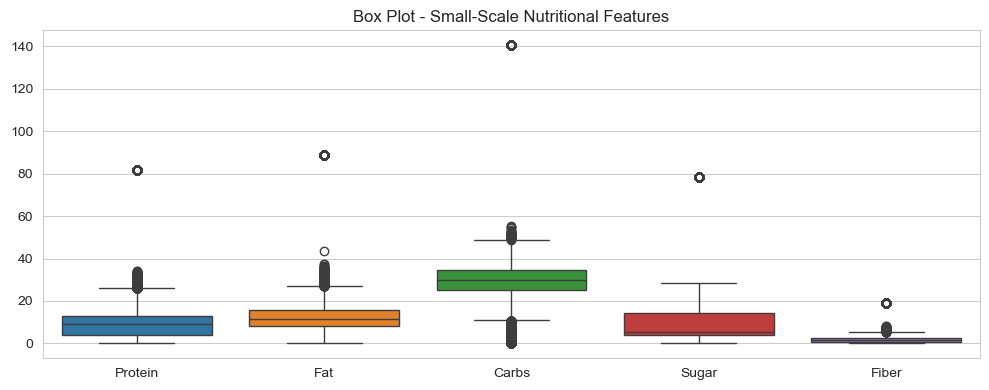

In [25]:
# Group 1: features with small values
small_scale = ['Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber']
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[small_scale])
plt.title('Box Plot - Small-Scale Nutritional Features')
plt.tight_layout()
plt.show()

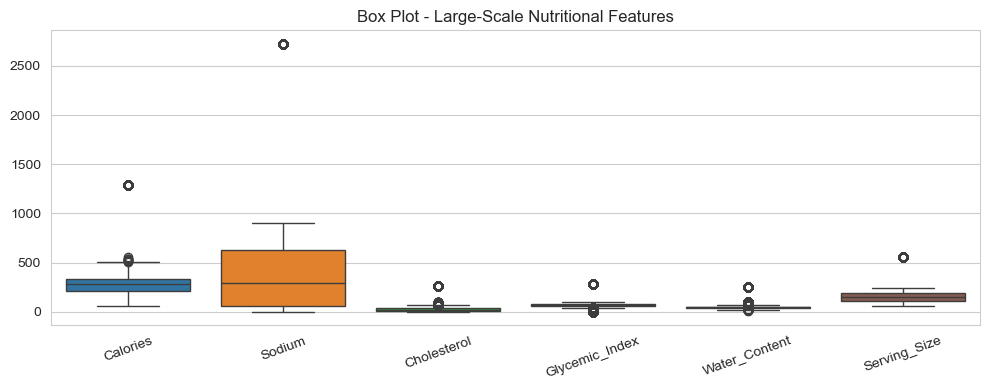

In [27]:
# Group 2: features with large values
large_scale = ['Calories', 'Sodium', 'Cholesterol', 'Glycemic_Index',
               'Water_Content', 'Serving_Size']
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[large_scale])
plt.title('Box Plot - Large-Scale Nutritional Features')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

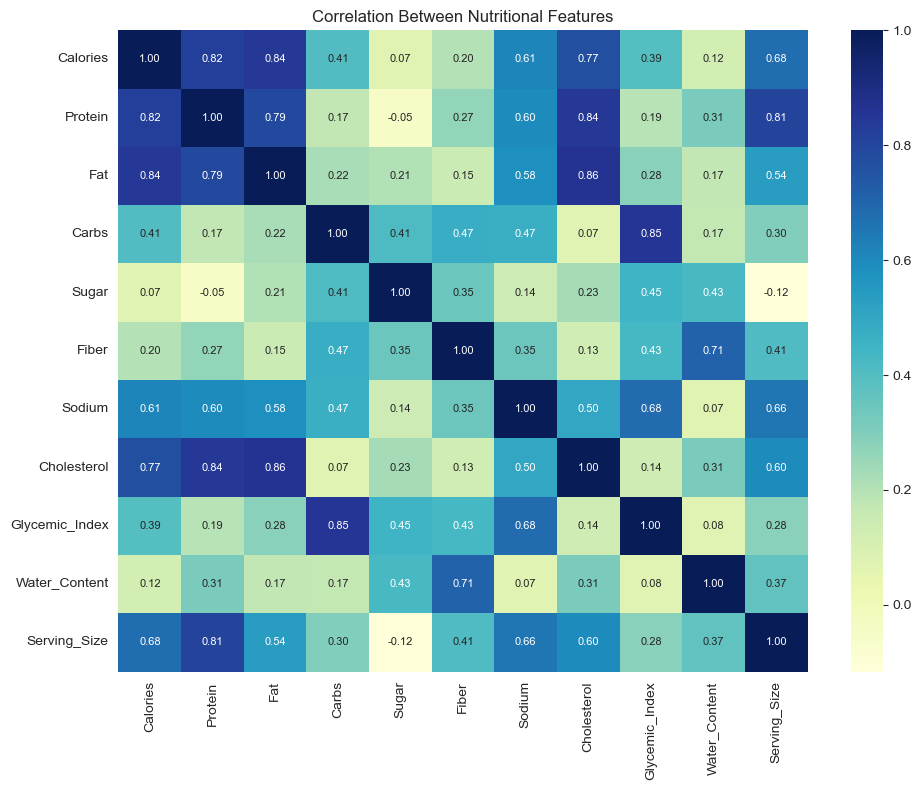

In [29]:
# Correlation heatmap - which nutrients move together
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f',
            annot_kws={'size': 8})
plt.title('Correlation Between Nutritional Features')
plt.tight_layout()
plt.show()

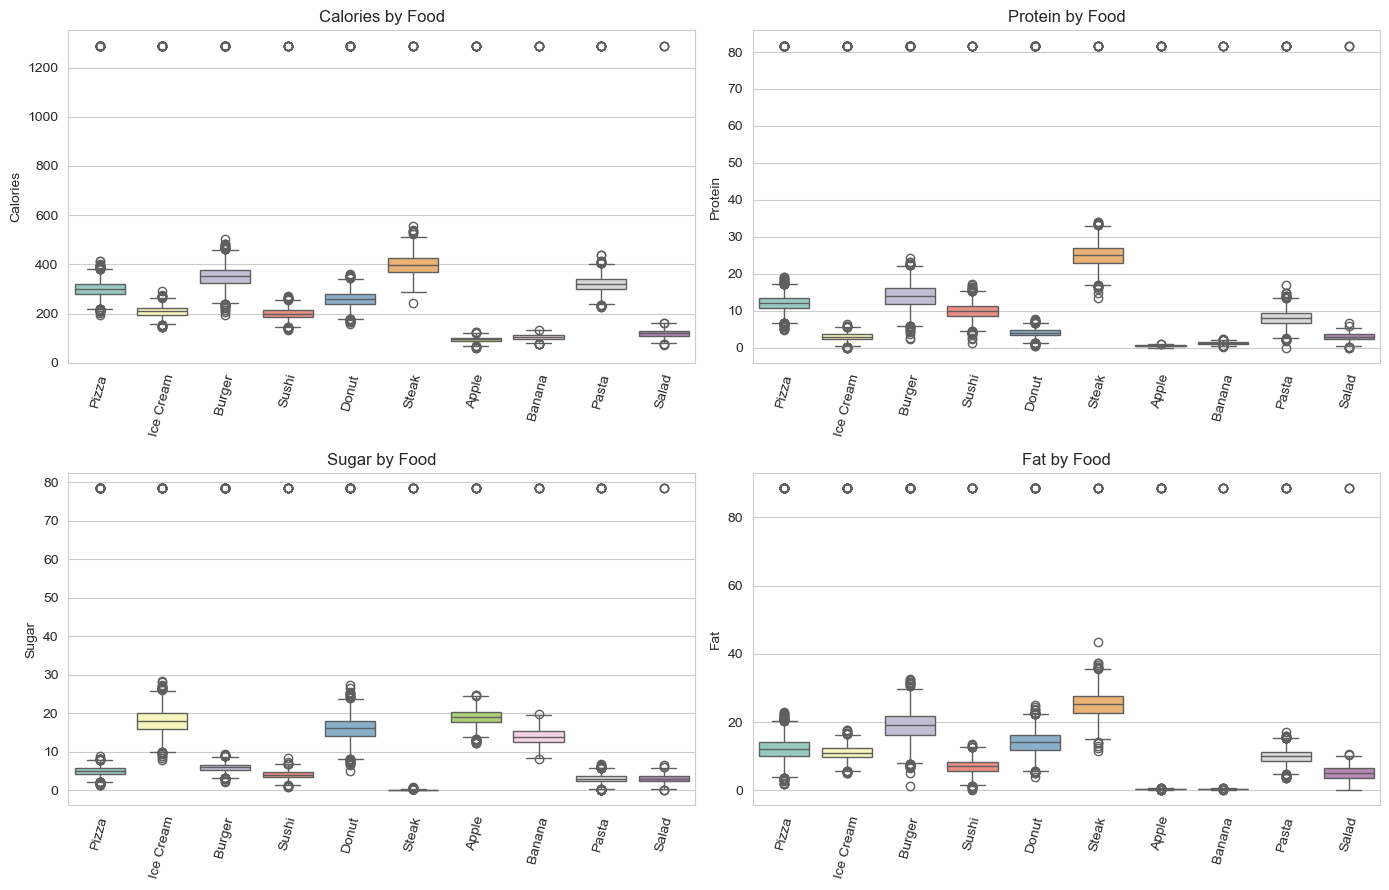

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), ['Calories', 'Protein', 'Sugar', 'Fat']):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=ax, palette='Set3')
    ax.set_title(col + ' by Food')
    ax.tick_params(axis='x', rotation=75)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [33]:
print("Missing values before:", df.isnull().sum().sum())

# Drop rows where the target (food name) is missing
df = df.dropna(subset=[TARGET_COLUMN])

# Fill missing numeric values with the median of that column
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after :", df.isnull().sum().sum())
print("Rows remaining       :", df.shape[0])

Missing values before: 4125
Missing values after : 0
Rows remaining       : 31700


In [35]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Duplicates removed:", before - after)
print("Rows remaining    :", after)

Duplicates removed: 313
Rows remaining    : 31387


In [37]:
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)      # 25th percentile
    Q3  = df[col].quantile(0.75)      # 75th percentile
    IQR = Q3 - Q1                     # inter-quartile range

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()

    # Cap the values at the limits
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

    print("{:<16} {} outliers capped".format(col + ':', n_outliers))

Calories:        94 outliers capped
Protein:         859 outliers capped
Fat:             808 outliers capped
Carbs:           2730 outliers capped
Sugar:           84 outliers capped
Fiber:           480 outliers capped
Sodium:          84 outliers capped
Cholesterol:     2046 outliers capped
Glycemic_Index:  3125 outliers capped
Water_Content:   3326 outliers capped
Serving_Size:    84 outliers capped


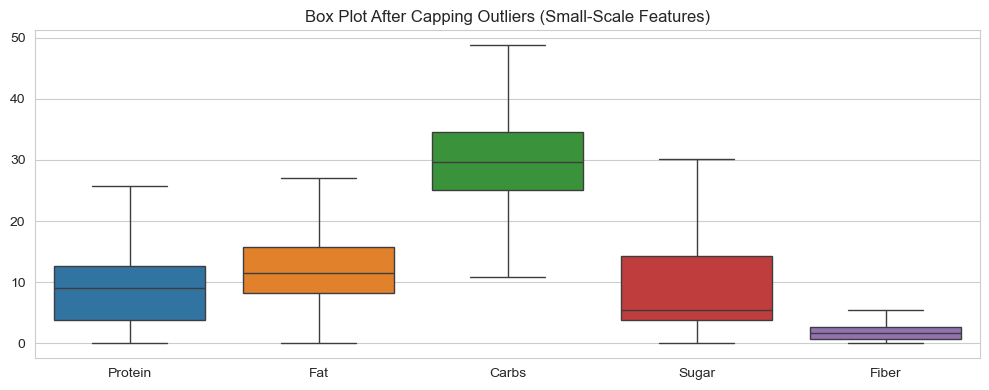

In [39]:
# Box plot again - the extreme points should now be gone
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[small_scale])
plt.title('Box Plot After Capping Outliers (Small-Scale Features)')
plt.tight_layout()
plt.show()

In [41]:
# Boolean -> 1 / 0
for col in boolean_cols:
    df[col] = df[col].astype(int)

df[boolean_cols].head()

,Is_Vegan,Is_Gluten_Free
0,0,0
1,0,1
2,0,0
3,0,1
4,0,0


In [43]:
# Separate the features (X) from the target (y)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# One-hot encode the two text columns
X = pd.get_dummies(X, columns=categorical_cols)

# get_dummies creates True/False columns, so convert everything to numbers
X = X.astype(float)

print("Number of features after encoding:", X.shape[1])
print("\nFeature columns:")
print(list(X.columns))

Number of features after encoding: 21

Feature columns:
['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Is_Vegan', 'Is_Gluten_Free', 'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch', 'Meal_Type_snack', 'Preparation_Method_baked', 'Preparation_Method_fried', 'Preparation_Method_grilled', 'Preparation_Method_raw']


In [45]:
X.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Vegan,Is_Gluten_Free,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show the scaled result
pd.DataFrame(X_scaled, columns=X.columns).head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Vegan,Is_Gluten_Free,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,0.243520,0.836749,0.317656,0.735682,-0.531377,-0.402021,1.148336,-0.007100,1.142990,-0.092108,...,-0.363881,-0.791638,-0.578687,1.739106,-0.574616,-0.581091,-0.583396,1.756792,-0.578393,-0.578393
1,-0.648228,-0.823692,-0.073232,-0.724253,1.253716,-1.276747,-0.925378,0.536603,0.274922,0.247719,...,-0.363881,1.263204,-0.578687,-0.575008,-0.574616,1.720902,-0.583396,-0.569219,-0.578393,1.728929
2,0.704439,0.834584,1.181751,0.034357,-0.310853,-0.776398,1.204276,0.566685,-0.227055,-0.541627,...,-0.363881,-0.791638,-0.578687,-0.575008,-0.574616,1.720902,-0.583396,-0.569219,-0.578393,1.728929
3,-0.814990,0.045687,-1.022364,0.351692,-0.817029,-0.086344,-0.093798,0.198478,0.214884,0.862291,...,-0.363881,1.263204,-0.578687,-0.575008,1.740294,-0.581091,-0.583396,1.756792,-0.578393,-0.578393
4,0.060587,-0.496977,0.642501,0.067981,1.409472,-0.270756,-0.109681,-0.566907,0.337043,-1.106943,...,-0.363881,-0.791638,-0.578687,-0.575008,-0.574616,1.720902,1.714101,-0.569219,-0.578393,-0.578393


In [49]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_

print("Number of classes:", len(class_names))
print("\nEncoding used:")
for number, name in enumerate(class_names):
    print("  {} -> {}".format(number, name))

Number of classes: 10

Encoding used:
  0 -> Apple
  1 -> Banana
  2 -> Burger
  3 -> Donut
  4 -> Ice Cream
  5 -> Pasta
  6 -> Pizza
  7 -> Salad
  8 -> Steak
  9 -> Sushi


In [51]:
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

print("Features before PCA:", X_scaled.shape[1])
print("Features after PCA :", X_pca.shape[1])
print("Variance retained  : {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))

Features before PCA: 21
Features after PCA : 12
Variance retained  : 95.31%


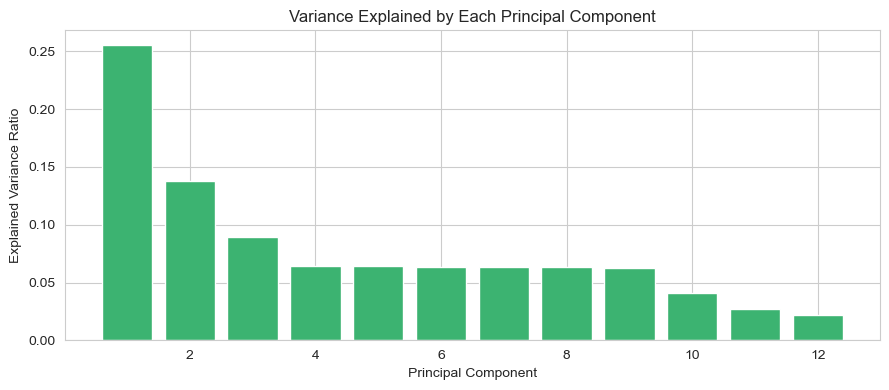

In [53]:
plt.figure(figsize=(9, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_, color='mediumseagreen')
plt.title('Variance Explained by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.tight_layout()
plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])

Training samples: 25109
Test samples    : 6278


In [57]:
# This list will collect the scores of every model for the final comparison
results = []

def evaluate_model(model_name, y_true, y_pred):
    """Calculate, print and plot the evaluation scores for one model."""

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print("=" * 55)
    print("Evaluation Scores -", model_name)
    print("=" * 55)
    print("Accuracy  : {:.4f}   ({:.2f}%)".format(accuracy, accuracy * 100))
    print("Precision : {:.4f}".format(precision))
    print("Recall    : {:.4f}".format(recall))
    print("F1-score  : {:.4f}".format(f1))

    # Per-class report, so we can see how the small classes did
    print("\nDetailed report for each food:")
    print(classification_report(y_true, y_pred,
                                target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - ' + model_name)
    plt.xlabel('Predicted Food')
    plt.ylabel('Actual Food')
    plt.tight_layout()
    plt.show()

    # Save the scores for Step 8
    results.append({'Model': model_name, 'Accuracy': accuracy,
                    'Precision': precision, 'Recall': recall, 'F1-score': f1})

print("Helper function ready.")

Helper function ready.


logistic Regression 

In [60]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_model.fit(X_train, y_train)

print('Logistic Regression trained.')

Logistic Regression trained.


In [62]:
y_pred_lr = lr_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_lr[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - Logistic Regression
Accuracy  : 0.9842   (98.42%)
Precision : 0.9843
Recall    : 0.9842
F1-score  : 0.9842

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.99      0.97      0.98       297
      Banana       0.97      0.98      0.98       239
      Burger       0.96      0.96      0.96       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       1.00      0.99      1.00       795
       Pizza       0.96      0.97      0.97      1183
       Salad       0.99      1.00      0.99       199
       Steak       1.00      1.00      1.00       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.98      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.98      0.98      0.98      6278



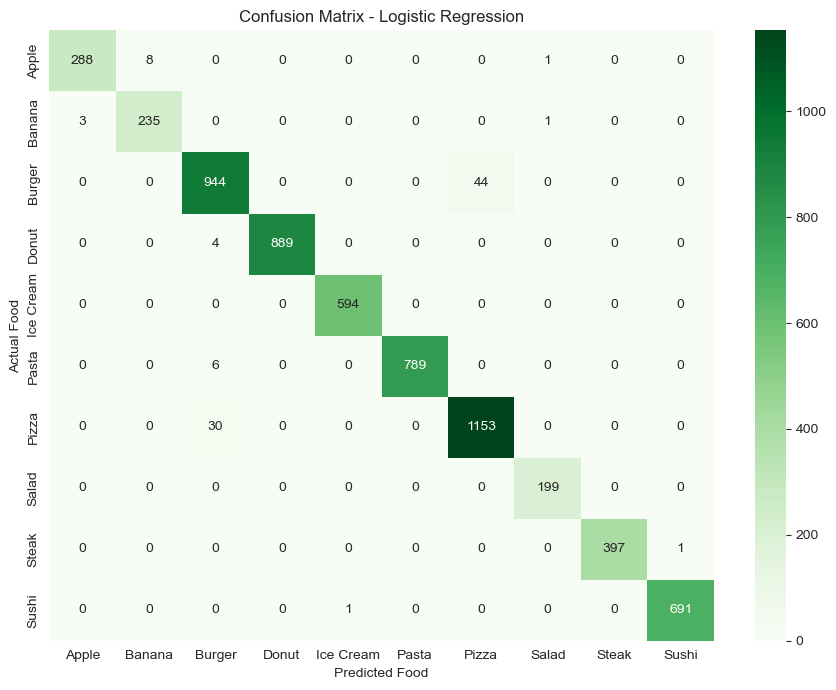

In [64]:
evaluate_model('Logistic Regression', y_test, y_pred_lr)

Decision Tree

In [67]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_SEED)
dt_model.fit(X_train, y_train)

print('Decision Tree trained.')

Decision Tree trained.


In [69]:
y_pred_dt = dt_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_dt[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - Decision Tree
Accuracy  : 0.9755   (97.55%)
Precision : 0.9755
Recall    : 0.9755
F1-score  : 0.9755

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.98      0.96      0.97       297
      Banana       0.94      0.97      0.95       239
      Burger       0.94      0.94      0.94       988
       Donut       0.99      1.00      0.99       893
   Ice Cream       0.99      1.00      0.99       594
       Pasta       1.00      0.99      0.99       795
       Pizza       0.95      0.96      0.95      1183
       Salad       1.00      0.99      0.99       199
       Steak       1.00      1.00      1.00       398
       Sushi       0.99      0.99      0.99       692

    accuracy                           0.98      6278
   macro avg       0.98      0.98      0.98      6278
weighted avg       0.98      0.98      0.98      6278



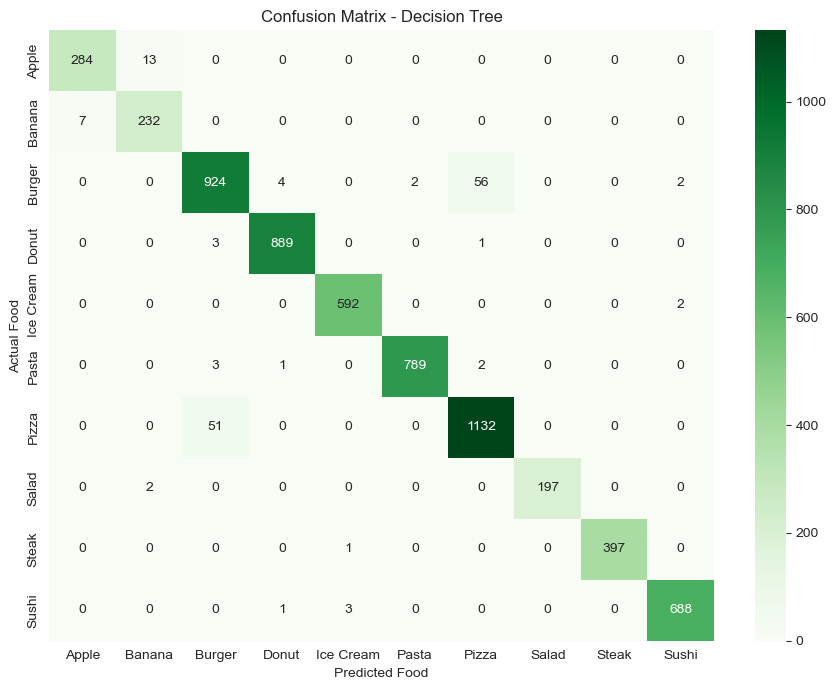

In [71]:
evaluate_model('Decision Tree', y_test, y_pred_dt)

Random Forest 

In [74]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

print('Random Forest trained.')

Random Forest trained.


In [76]:
y_pred_rf = rf_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_rf[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Steak', 'Ice Cream', 'Sushi']


Evaluation Scores - Random Forest
Accuracy  : 0.9849   (98.49%)
Precision : 0.9849
Recall    : 0.9849
F1-score  : 0.9849

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.99      0.97      0.98       297
      Banana       0.96      0.98      0.97       239
      Burger       0.97      0.96      0.97       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.97      0.98      0.97      1183
       Salad       1.00      0.99      1.00       199
       Steak       0.99      1.00      0.99       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.98      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.98      0.98      0.98      6278



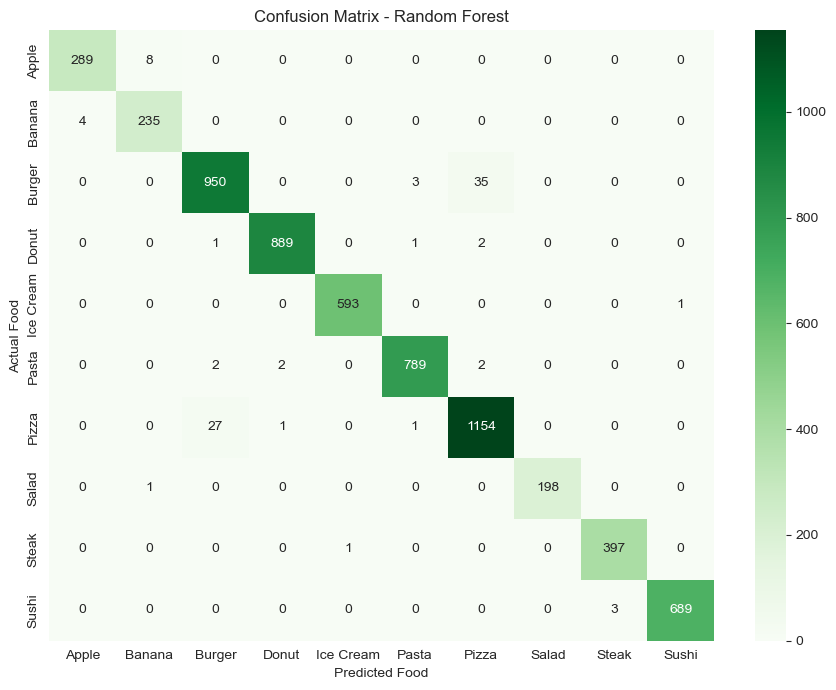

In [78]:
evaluate_model('Random Forest', y_test, y_pred_rf)

KNN

In [81]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print('KNN trained.')

KNN trained.


In [83]:
y_pred_knn = knn_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_knn[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - K-Nearest Neighbors
Accuracy  : 0.9844   (98.44%)
Precision : 0.9844
Recall    : 0.9844
F1-score  : 0.9844

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.97      0.97      0.97       297
      Banana       0.96      0.96      0.96       239
      Burger       0.98      0.95      0.97       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.97      0.98      0.97      1183
       Salad       1.00      0.99      1.00       199
       Steak       1.00      1.00      1.00       398
       Sushi       0.99      1.00      0.99       692

    accuracy                           0.98      6278
   macro avg       0.99      0.98      0.98      6278
weighted avg       0.98      0.98      0.98      6278



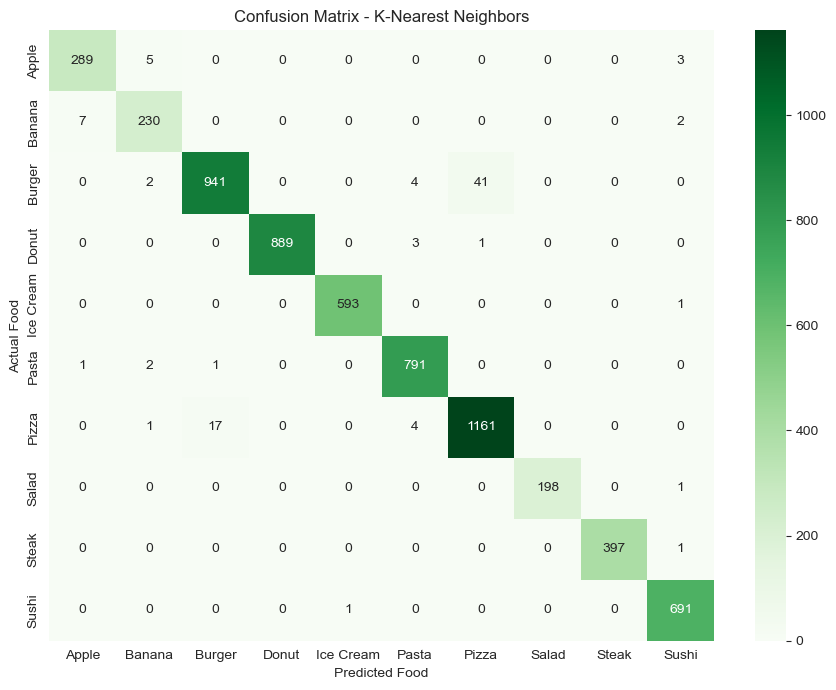

In [85]:
evaluate_model('K-Nearest Neighbors', y_test, y_pred_knn)

SVM

In [88]:
svm_model = SVC(kernel='rbf', random_state=RANDOM_SEED)
svm_model.fit(X_train, y_train)

print('SVM trained.')

SVM trained.


In [90]:
y_pred_svm = svm_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_svm[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - Support Vector Machine
Accuracy  : 0.9879   (98.79%)
Precision : 0.9879
Recall    : 0.9879
F1-score  : 0.9879

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.99      0.98      0.99       297
      Banana       0.99      0.98      0.99       239
      Burger       0.98      0.97      0.97       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       0.99      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.97      0.98      0.98      1183
       Salad       1.00      0.99      1.00       199
       Steak       1.00      1.00      1.00       398
       Sushi       0.99      1.00      0.99       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



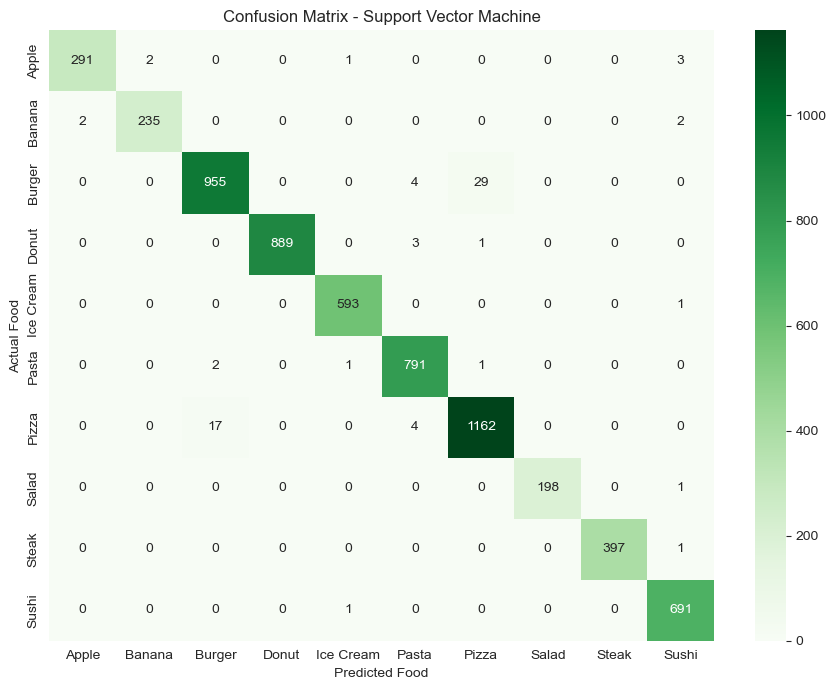

In [92]:
evaluate_model('Support Vector Machine', y_test, y_pred_svm)

XGB

In [95]:
xgb_model = XGBClassifier(n_estimators=100, random_state=RANDOM_SEED,
                          eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

print('XGBoost trained.')

XGBoost trained.


In [97]:
y_pred_xgb = xgb_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_xgb[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - XGBoost
Accuracy  : 0.9850   (98.50%)
Precision : 0.9850
Recall    : 0.9850
F1-score  : 0.9850

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.99      0.98      0.98       297
      Banana       0.98      0.97      0.98       239
      Burger       0.97      0.96      0.97       988
       Donut       1.00      1.00      1.00       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.97      0.98      0.97      1183
       Salad       0.99      0.99      0.99       199
       Steak       1.00      1.00      1.00       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



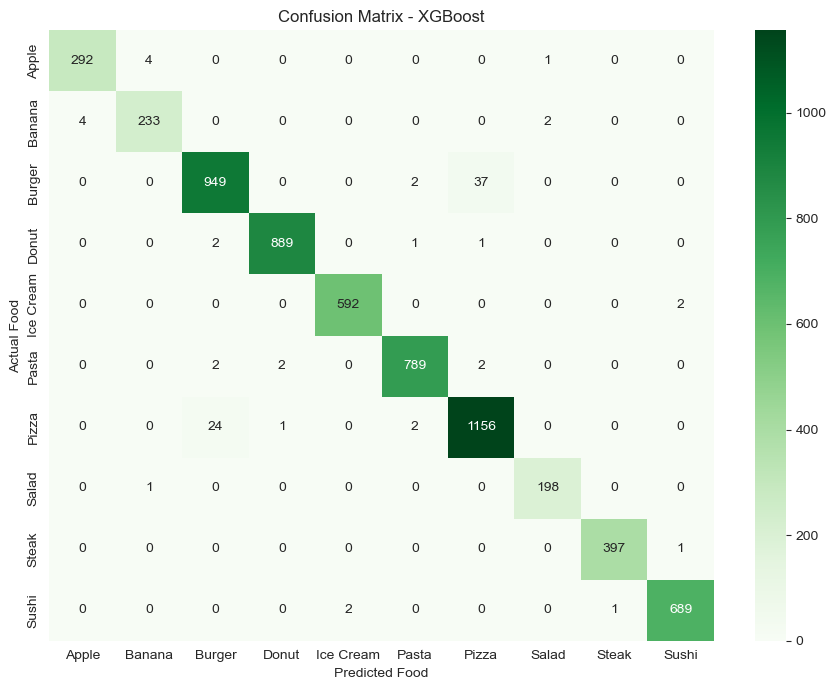

In [99]:
evaluate_model('XGBoost', y_test, y_pred_xgb)

Gradient Boost

In [102]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)
gb_model.fit(X_train, y_train)

print('Gradient Boosting trained.')

Gradient Boosting trained.


In [104]:
y_pred_gb = gb_model.predict(X_test)

print('First 10 predictions:', list(label_encoder.inverse_transform(y_pred_gb[:10])))

First 10 predictions: ['Apple', 'Pasta', 'Pizza', 'Donut', 'Pasta', 'Pizza', 'Banana', 'Ice Cream', 'Ice Cream', 'Sushi']


Evaluation Scores - Gradient Boosting Classifier
Accuracy  : 0.9847   (98.47%)
Precision : 0.9847
Recall    : 0.9847
F1-score  : 0.9847

Detailed report for each food:
              precision    recall  f1-score   support

       Apple       0.99      0.97      0.98       297
      Banana       0.96      0.98      0.97       239
      Burger       0.97      0.96      0.97       988
       Donut       0.99      0.99      0.99       893
   Ice Cream       1.00      1.00      1.00       594
       Pasta       0.99      0.99      0.99       795
       Pizza       0.97      0.98      0.97      1183
       Salad       0.99      0.99      0.99       199
       Steak       0.99      1.00      1.00       398
       Sushi       1.00      1.00      1.00       692

    accuracy                           0.98      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.98      0.98      0.98      6278



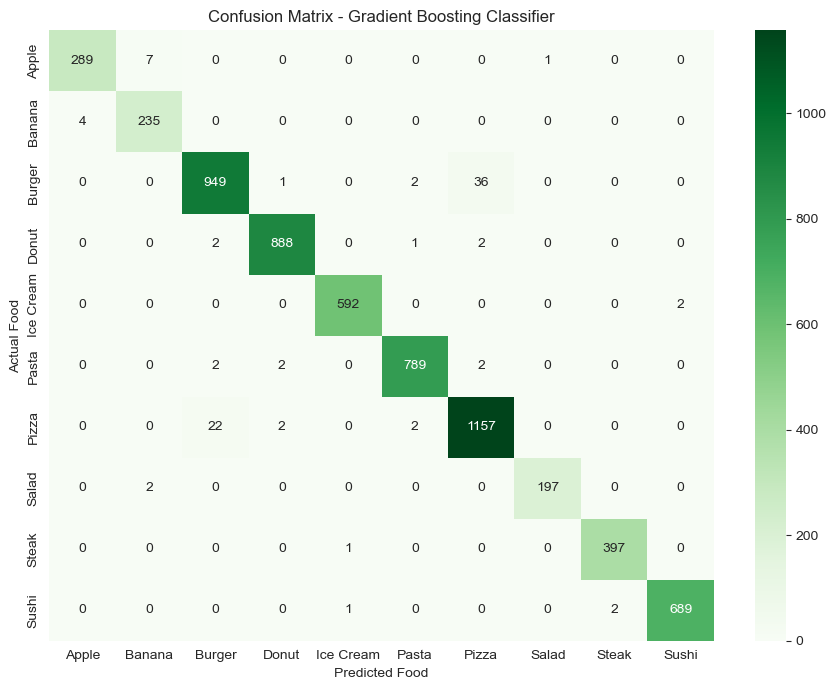

In [106]:
evaluate_model('Gradient Boosting Classifier', y_test, y_pred_gb)

compare 

In [109]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Support Vector Machine,0.987894,0.987915,0.987894,0.987884
1,XGBoost,0.985027,0.985044,0.985027,0.985024
2,Random Forest,0.984868,0.984902,0.984868,0.984872
3,Gradient Boosting Classifier,0.984709,0.984747,0.984709,0.984708
4,K-Nearest Neighbors,0.984390,0.984449,0.984390,0.984367
5,Logistic Regression,0.984231,0.984301,0.984231,0.984248
6,Decision Tree,0.975470,0.975525,0.975470,0.975477


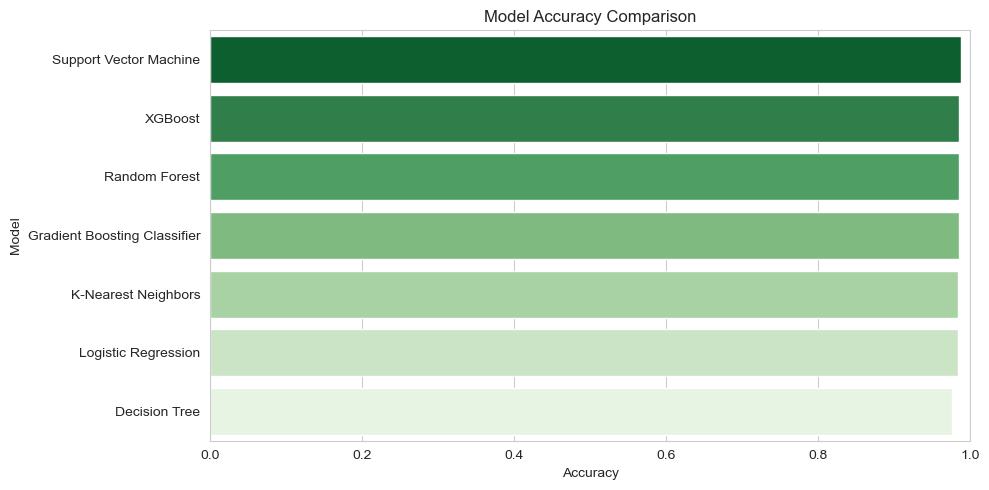

In [111]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='Greens_r')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

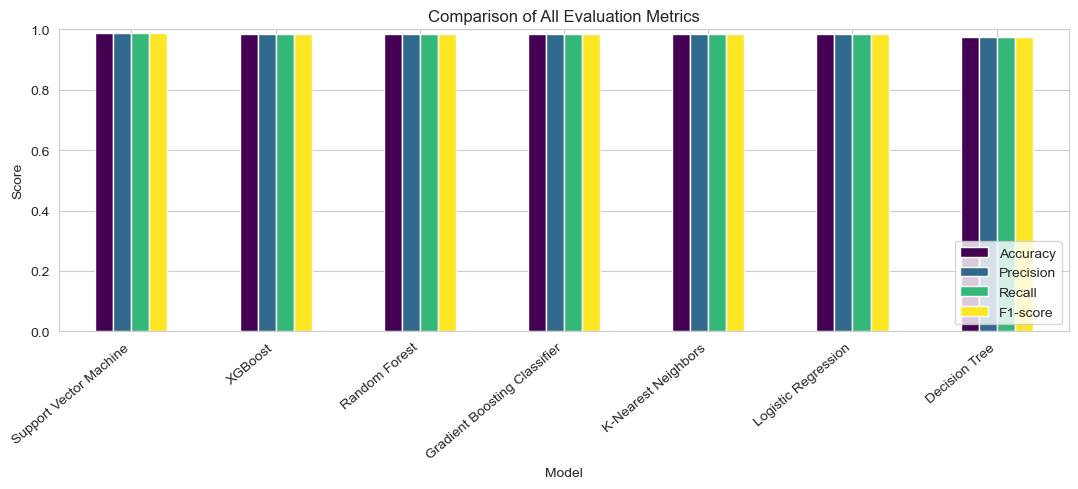

In [113]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(11, 5), colormap='viridis')
plt.title('Comparison of All Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=40, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [115]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy    = results_df.iloc[0]['Accuracy']

print("Best performing model: {}".format(best_model_name))
print("Accuracy: {:.4f}  ({:.2f}%)".format(best_accuracy, best_accuracy * 100))

Best performing model: Support Vector Machine
Accuracy: 0.9879  (98.79%)


In [117]:
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    X_pca, y_encoded, cv=5, scoring='accuracy')

print("Accuracy of each fold:", np.round(cv_scores, 4))
print("Mean accuracy        : {:.4f}".format(cv_scores.mean()))
print("Standard deviation   : {:.4f}".format(cv_scores.std()))

Accuracy of each fold: [0.978  0.9818 0.9836 0.9858 0.9882]
Mean accuracy        : 0.9835
Standard deviation   : 0.0035


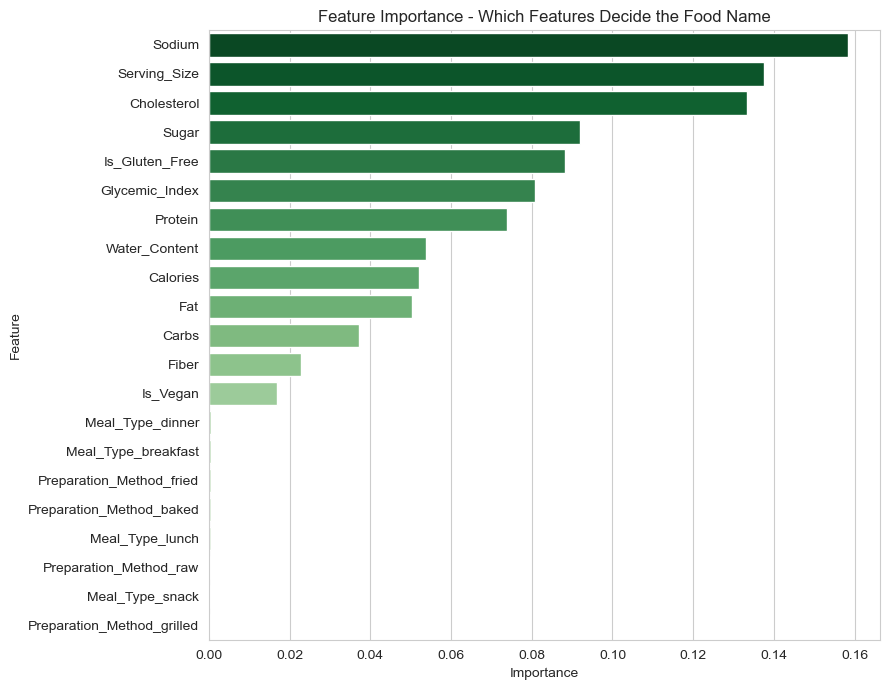

,Feature,Importance
6,Sodium,0.158395
10,Serving_Size,0.137535
7,Cholesterol,0.133244
4,Sugar,0.091857
12,Is_Gluten_Free,0.088286
8,Glycemic_Index,0.080843
1,Protein,0.073851
9,Water_Content,0.053722
0,Calories,0.052123
2,Fat,0.050286


In [119]:
rf_for_importance = RandomForestClassifier(n_estimators=100,
                                           random_state=RANDOM_SEED, n_jobs=-1)
rf_for_importance.fit(X_scaled, y_encoded)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_for_importance.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Greens_r')
plt.title('Feature Importance - Which Features Decide the Food Name')
plt.tight_layout()
plt.show()

importance_df

In [121]:
# All our trained models, kept in a dictionary
trained_models = {
    'Logistic Regression'          : lr_model,
    'Decision Tree'                : dt_model,
    'Random Forest'                : rf_model,
    'K-Nearest Neighbors'          : knn_model,
    'Support Vector Machine'       : svm_model,
    'XGBoost'                      : xgb_model,
    'Gradient Boosting Classifier' : gb_model
}

# best_model_name came from Step 8
final_model = trained_models[best_model_name]

print("Model chosen for the diet app:", best_model_name)
print("Its accuracy: {:.2f}%".format(best_accuracy * 100))

Model chosen for the diet app: Support Vector Machine
Its accuracy: 98.79%


In [123]:
def predict_food(user_goals, meal_type=None, preparation_method=None):
    """
    Predict the exact food name for a user's nutritional goal.

    user_goals         : dictionary of nutrition values, e.g. {'Protein': 30, 'Sugar': 2}
    meal_type          : optional - 'breakfast', 'lunch', 'dinner' or 'snack'
    preparation_method : optional - 'raw', 'fried', 'baked' or 'grilled'
    """

    # 1. Start with the median value of every feature as the default
    input_row = pd.DataFrame([X.median()], columns=X.columns)

    # 2a. Replace the nutrition values the user gave us
    for feature, value in user_goals.items():
        if feature in input_row.columns:
            input_row[feature] = value
        else:
            print("Warning: '{}' is not a known feature and was ignored.".format(feature))

    # 2b. Handle the one-hot encoded columns (set the chosen one to 1, the rest to 0)
    if meal_type is not None:
        for col in [c for c in X.columns if c.startswith('Meal_Type_')]:
            input_row[col] = 0.0
        input_row['Meal_Type_' + meal_type] = 1.0

    if preparation_method is not None:
        for col in [c for c in X.columns if c.startswith('Preparation_Method_')]:
            input_row[col] = 0.0
        input_row['Preparation_Method_' + preparation_method] = 1.0

    # 3. Apply the SAME scaler and PCA that were fitted on the training data
    input_scaled = scaler.transform(input_row)
    input_pca    = pca.transform(input_scaled)

    # 4. Predict, then turn the number back into a food name
    prediction = final_model.predict(input_pca)
    food_name  = label_encoder.inverse_transform(prediction)[0]

    return food_name

print("Prediction function ready.")

Prediction function ready.


Example 

In [126]:
user_goals = {
    'Calories'       : 400,
    'Protein'        : 25,    # high protein
    'Fat'            : 25,
    'Carbs'          : 2,     # very low carb
    'Sugar'          : 1,
    'Fiber'          : 0.5,
    'Sodium'         : 72,
    'Cholesterol'    : 90,
    'Glycemic_Index' : 2,     # very low GI
    'Water_Content'  : 56,
    'Serving_Size'   : 200
}

result = predict_food(user_goals, meal_type='dinner', preparation_method='grilled')

print("Goal      : high protein, very low carb, low glycemic index")
print("Meal type : dinner")
print("-" * 50)
print("Predicted food:", result)

Goal      : high protein, very low carb, low glycemic index
Meal type : dinner
--------------------------------------------------
Predicted food: Steak


In [128]:
user_goals = {
    'Calories'       : 100,   # low calorie
    'Protein'        : 1,
    'Fat'            : 1,
    'Carbs'          : 26,
    'Sugar'          : 20,
    'Fiber'          : 4.5,
    'Sodium'         : 17,    # very low sodium, typical of fruit
    'Cholesterol'    : 1,
    'Glycemic_Index' : 41,
    'Water_Content'  : 88,    # high water content
    'Serving_Size'   : 155
}

result = predict_food(user_goals, meal_type='snack', preparation_method='raw')

print("Goal      : low calorie, low sodium, high water content")
print("Meal type : snack")
print("-" * 50)
print("Predicted food:", result)

Goal      : low calorie, low sodium, high water content
Meal type : snack
--------------------------------------------------
Predicted food: Banana


In [130]:
user_goals = {
    'Calories'       : 120,
    'Protein'        : 3,
    'Fat'            : 5,
    'Carbs'          : 10,
    'Sugar'          : 3,
    'Fiber'          : 3,
    'Sodium'         : 150,
    'Cholesterol'    : 2,
    'Glycemic_Index' : 36,    # low GI
    'Water_Content'  : 90,    # very high water content
    'Serving_Size'   : 101
}

result = predict_food(user_goals, meal_type='lunch', preparation_method='raw')

print("Goal      : light, low glycemic index, high water content")
print("Meal type : lunch")
print("-" * 50)
print("Predicted food:", result)

Goal      : light, low glycemic index, high water content
Meal type : lunch
--------------------------------------------------
Predicted food: Salad
